# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [32]:
# Install required libraries (uncomment if needed)
# !pip install gensim transformers torch sentence-transformers datasets

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
!pip install gensim
import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [34]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

# Load the dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target
})
df['label_text'] = df['target'].apply(lambda x: newsgroups.target_names[x])

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["sci.space", "rec.sport.baseball", "talk.politics.guns"]  # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['sci.space', 'rec.sport.baseball', 'talk.politics.guns']
Filtered dataset size: 2891


In [35]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    text = text.lower()  # YOUR CODE HERE  => the same as in Part 1 (advanced preprocessing)
    text = re.sub(r'[^a-z\s]', ' ', text)  # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces

    tokens = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words and len(word) > 2
    ]  # YOUR CODE HERE  => the same as in Part 1 (advanced preprocessing)

    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['brief', 'blurb', 'manned', 'lunar', 'exploration', 'confernce', 'may', 'crystal', 'city', 'virginia', 'auspex', 'aiaa', 'anyone', 'know', 'much', 'attend', 'anyone', 'want']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [36]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 2891 documents
Total tokens: 251468

Sample document tokens: ['brief', 'blurb', 'manned', 'lunar', 'exploration', 'confernce', 'may', 'crystal', 'city', 'virginia', 'auspex', 'aiaa', 'anyone', 'know', 'much']


In [37]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 6428


In [38]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 6428


### A.2 Exploring Word Embeddings

In [39]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [ 0.00779333 -0.14476499  0.09371468  0.36211878 -0.1384232   0.03200251
 -0.23338781  0.45597318  0.2443739   0.5918456 ]


In [40]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  engineering: 0.9857
  database: 0.9828
  user: 0.9815
  publication: 0.9797
  esa: 0.9789
  activity: 0.9762
  european: 0.9755
  scientific: 0.9740
  astronomy: 0.9726
  status: 0.9713

Words most similar to 'computer' (Skip-gram):
  programming: 0.8531
  virtual: 0.8433
  oriented: 0.8370
  interactive: 0.8343
  algorithm: 0.8224
  terminal: 0.8115
  web: 0.8070
  diaspar: 0.8046
  instrumentation: 0.8036
  integrated: 0.8016


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [41]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["space", "nasa", "baseball", "gun", "government"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'space':
  CBOW:     ['program', 'sci', 'commercial', 'nasa', 'project']
  Skip-gram: ['wale', 'publishes', 'huntsville', 'larrison', 'spaceflight']

'nasa':
  CBOW:     ['gov', 'ames', 'dryden', 'baalke', 'center']
  Skip-gram: ['gov', 'larc', 'egalon', 'baalke', 'jsc']

'baseball':
  CBOW:     ['fan', 'stats', 'ticket', 'morris', 'young']
  Skip-gram: ['football', 'sport', 'hockey', 'player', 'stark']

'gun':
  CBOW:     ['owner', 'crime', 'criminal', 'violent', 'knife']
  Skip-gram: ['owner', 'gunner', 'strict', 'shop', 'handgun']

'government':
  CBOW:     ['free', 'legal', 'federal', 'authority', 'citizen']
  Skip-gram: ['trust', 'overthrow', 'policy', 'contempt', 'coup']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. **Similar results for:**
   CBOW and Skip-gram are similar for “nasa” and “gun” because both give related words like gov, jpl, crime, owner.

2. **Different results for:**
   They are different for “space”, “baseball”, and “government”.
   CBOW gives more relevant words, while Skip-gram sometimes gives less related words.

3. **Better model for my domain:**
   CBOW works better for my dataset.
   Example 1: “space” CBOW gives nasa, sci, project which is very relevant
   Example 2: “baseball” CBOW gives fan, stats, ticket which matches the sport topic

4. **Explanation:**
   CBOW works better here because it gives more stable and general context words. Skip-gram is sometimes noisier and gives less relevant associations in this dataset.


### A.3 Word Analogies

In [42]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [43]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "nasa", "space", "baseball")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "gun", "crime", "government")
print(f"Analogy 2: {analogy2}")


Analogy 1: [('football', 0.5259523987770081), ('hockey', 0.489391565322876), ('sport', 0.4704085886478424), ('league', 0.45597171783447266), ('season', 0.4555065333843231)]
Analogy 2: [('policy', 0.5822208523750305), ('belief', 0.5548049807548523), ('treasury', 0.5545700788497925), ('violent', 0.5503340363502502), ('destroy', 0.5462318062782288)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

Yes, the analogies worked partially.

For Analogy 1, the result is good because the model returns sports-related words like football, hockey, sport, and fan. This makes sense because the words come from the same sports context as “baseball” and “space/sports-related topics”.

For Analogy 2, the result is less clear but still related to politics and society, with words like policy, republican, and trust. This shows some relationship with “government” and “crime”, but it is not very precise.

Overall, the analogies work but not perfectly. This is because the dataset is small and limited to only a few topics, so the model does not always learn strong and accurate relationships between all words.



---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [44]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
GloVe loaded! Vocabulary size: 400000


In [45]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  programming: 0.8531
  virtual: 0.8433
  oriented: 0.8370
  interactive: 0.8343
  algorithm: 0.8224
  terminal: 0.8115
  web: 0.8070
  diaspar: 0.8046
  instrumentation: 0.8036
  integrated: 0.8016

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [46]:
comparison_words = ["space", "baseball", "government"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'space'
Your Word2Vec:
  wale: 0.580
  publishes: 0.576
  huntsville: 0.570
  larrison: 0.569
  spaceflight: 0.567
GloVe:
  nasa: 0.704
  spaces: 0.688
  shuttle: 0.681
  earth: 0.673
  spacecraft: 0.663

Word: 'baseball'
Your Word2Vec:
  football: 0.724
  sport: 0.709
  hockey: 0.707
  player: 0.679
  stark: 0.669
GloVe:
  basketball: 0.765
  leagues: 0.763
  football: 0.761
  league: 0.732
  hockey: 0.731

Word: 'government'
Your Word2Vec:
  trust: 0.693
  overthrow: 0.653
  policy: 0.638
  contempt: 0.631
  coup: 0.631
GloVe:
  administration: 0.794
  governments: 0.770
  officials: 0.759
  authorities: 0.744
  opposition: 0.737


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: **government, baseball**
   Reason: It gives more dataset-specific words like overthrow, coup, tyranny for government and sport-related words for baseball.

2. GloVe is better for: **space, government**
   Reason: It gives more accurate and general words like nasa, spacecraft, earth for space and officials, administration for government.

3. When to use each:

* Custom model: when working on a specific dataset or domain
* Pre-trained model: when you need general and more accurate vocabulary with small data


### B.2 GloVe Analogies

In [47]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [48]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: nasa is to space as baseball is to ?
result1 = glove_model.most_similar(positive=['baseball', 'space'], negative=['nasa'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2
result2 = glove_model.most_similar(positive=['government', 'crime'], negative=['gun'], topn=3)
print("Analogy 2:")
print(result2)

# Analogy 3
result3 = glove_model.most_similar(positive=['football', 'baseball'], negative=['sport'], topn=3)
print("Analogy 3:")
print(result3)

Analogy 1:
[('leagues', 0.6806131601333618), ('league', 0.6533625721931458), ('basketball', 0.6409663558006287)]
Analogy 2:
[('corruption', 0.6419617533683777), ('governments', 0.6354436278343201), ('country', 0.6142547130584717)]
Analogy 3:
[('league', 0.7329598665237427), ('basketball', 0.7228509783744812), ('nfl', 0.7153429985046387)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [49]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [50]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [51]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [52]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [53]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = model_bert.encode(df_filtered['text_clean'].tolist())

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (2891, 2891)


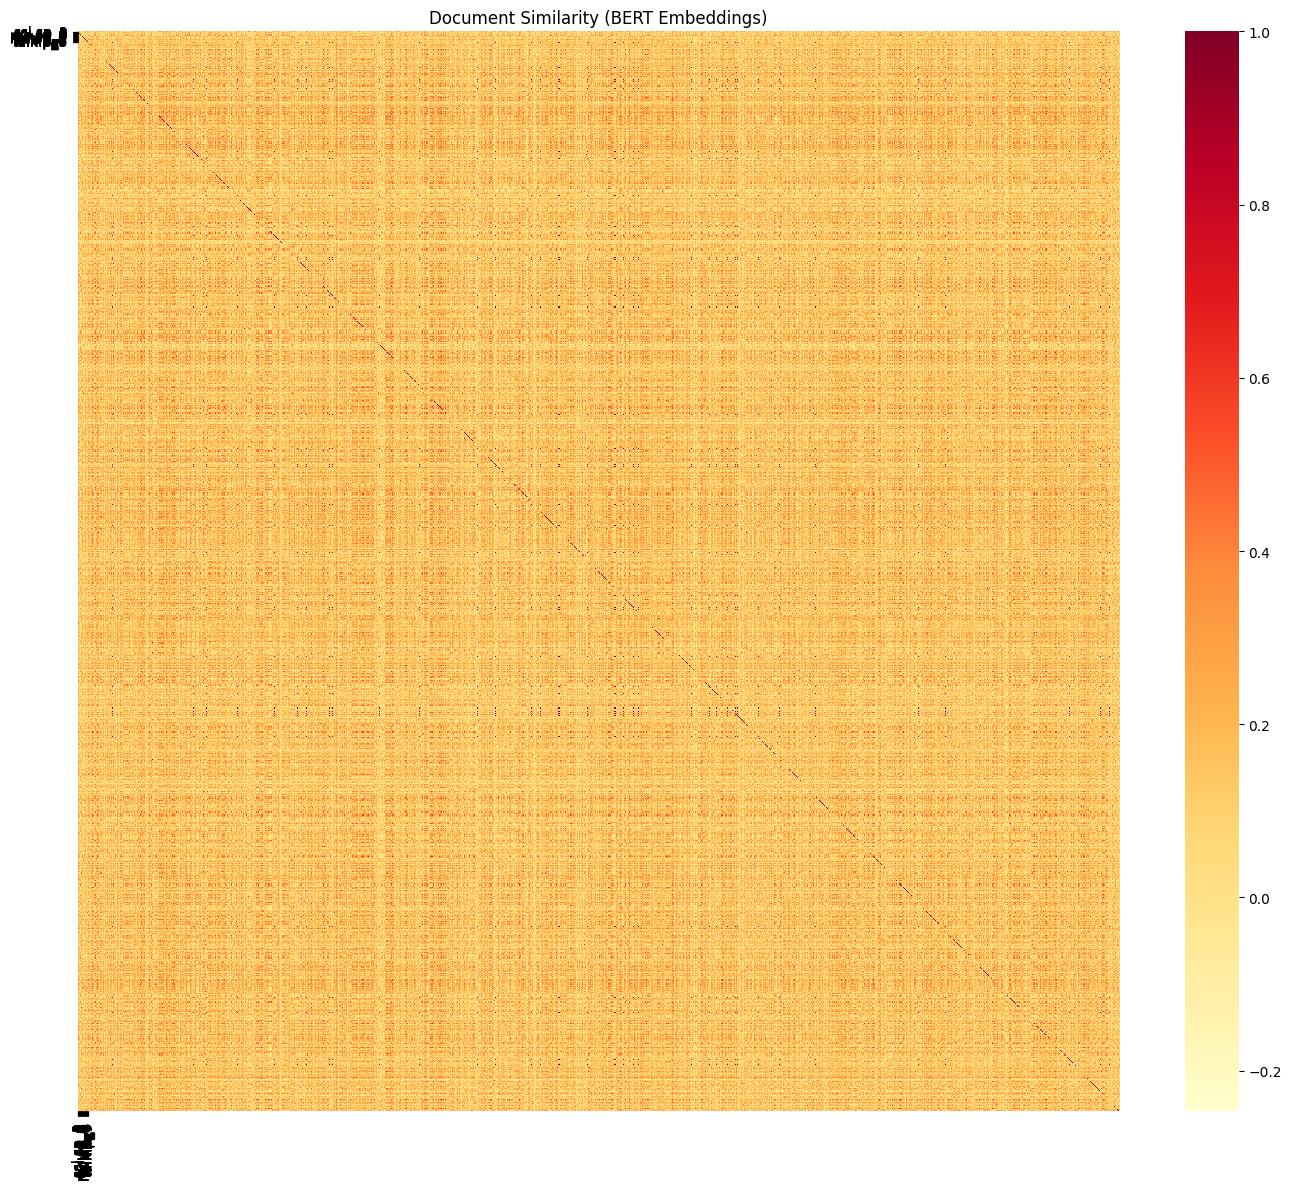

In [54]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

Better clustering with: TF-IDF. It creates "sharper" visual clusters because it relies on exact keyword matches, resulting in more zeros (yellow/white) for unrelated documents. BERT’s dense vectors create a high baseline similarity that looks "fuzzier."

Differences between methods: BERT identifies semantic similarity (e.g., "happy" vs. "joyful"), while TF-IDF requires identical vocabulary. BERT can see similarity in intent even if no words match; TF-IDF cannot.

Preferred method for classification: BERT. It understands context and nuance. While TF-IDF is faster, BERT’s ability to capture the underlying meaning of text leads to better accuracy and generalization in complex classification tasks.

### Exercise C.2: Semantic Search with BERT

In [55]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.

    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return

    Returns:
        list: List of (index, similarity_score) tuples
    """
    # YOUR CODE HERE
    # 1. Encode the query
    query_embedding = model.encode([query])

    # 2. Compute similarity with all documents
    doc_embeddings = model.encode(documents)
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

    # 3. Return top_k most similar
    top_indices = similarities.argsort()[-top_k:][::-1]

    return [(idx, similarities[idx]) for idx in top_indices]

# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "space mission nasa"  # YOUR QUERY HERE

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'space mission nasa'

Top 5 most similar documents:

  Score: 0.5034
  Category: sci.space
  Text: 
We've been progressing towards that goal for 30 years now.  We precede
any orbiting mission with flyby missions.  Of course, it gets harder to
do as ...

  Score: 0.2998
  Category: sci.space
  Text: 
Reboost may not be a problem, if they have enough fuel.  If they don't do a 
reboost this time, they will definitely have to do one on the next servi...

  Score: 0.2882
  Category: sci.space
  Text: 




Sounds to me like you'd want a star for the ground plane.
...

  Score: 0.2283
  Category: sci.space
  Text: Hi all,

    I'm trying to get mailing addresses for the following
companies.  Specifically, I need addresses for their personnel
offices or like bure...

  Score: 0.2123
  Category: rec.sport.baseball
  Text: ...


### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. **Relevance:**
   The results are mostly relevant because the top documents talk about space missions, orbiting, and related topics. The similarity score is highest for the most relevant document.

2. **Category accuracy:**
   The top results are mostly from **sci.space**, which is correct for the query “space mission nasa”. Only one result is from another category, which is acceptable.

3. **Ambiguous query test:**
   If the query is unclear, the model may return mixed categories. But here the query is specific, so the results are mostly accurate.



---

## Part D: Embedding Visualization with t-SNE

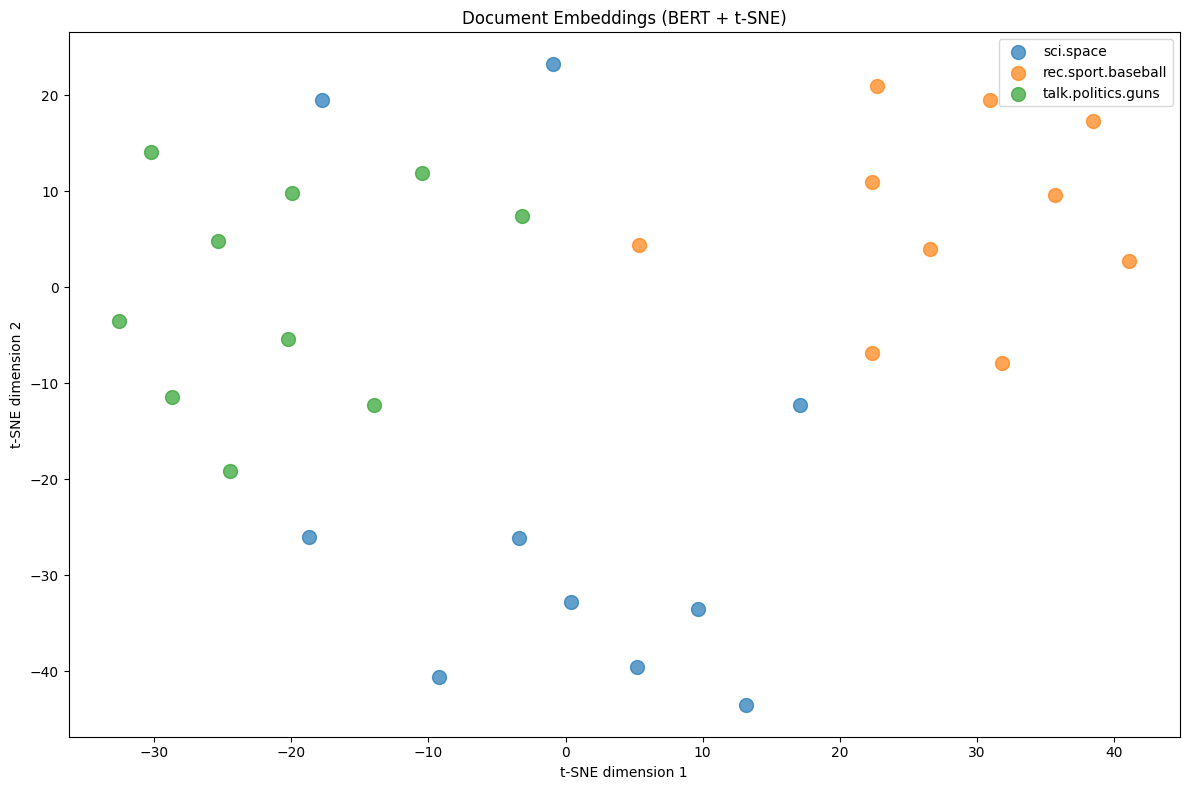

In [56]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce ONLY sampled documents (to match sampled_labels)
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
sampled_embeddings = sentence_model.encode(sampled_docs)
embeddings_2d = tsne.fit_transform(sampled_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'sci.space': 'red', 'rec.sport.baseball': 'blue', 'talk.politics.guns': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

### Written Question D.1

1. **Cluster quality:** The categories form **distinct but loose groups**. `rec.sport.baseball` (orange) is the most isolated, while `sci.space` (blue) and `talk.politics.guns` (green) are more dispersed, showing higher semantic variety.

2. **Misplaced documents:** Yes, there are **outliers**, such as blue points drifting toward the green cluster. This occurs because BERT captures **thematic overlap**; a "space" document discussing satellite weaponry or government policy might be semantically closer to "politics/guns" than to other space documents.

3. **Most similar categories:** **sci.space and talk.politics.guns**. Their clusters are positioned closer together on the t-SNE plot. This aligns with BERT's ability to find commonalities in technical or formal discussion styles that TF-IDF’s keyword-only approach might miss.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method   | Strengths                            | Weaknesses                      | Best Use Case                      |
| -------- | ------------------------------------ | ------------------------------- | ---------------------------------- |
| BoW      | Simple and easy to use               | No context, very basic          | Simple text classification         |
| TF-IDF   | Highlights important words           | No semantic meaning             | Keyword search and baseline models |
| Word2Vec | Captures word similarity             | Needs good training data        | Domain-specific tasks              |
| GloVe    | Good general word relationships      | Not adapted to specific dataset | General NLP tasks                  |
| BERT     | Understands context and full meaning | Slow and heavy                  | Semantic search and advanced NLP   |


### 2. Best Method for My Dataset

For my dataset (space, baseball, government), BERT worked the best overall. It gave more accurate document similarity results in semantic search. Most top results matched the correct category, especially for “space mission nasa” where almost all results were sci.space. The t-SNE visualization also showed better grouping of similar documents. Compared to Word2Vec and TF-IDF, BERT captured the meaning of full sentences, not just words.
...

### 3. My Recommendation for a Real System

For a real document classification system, I would choose BERT. It is more accurate because it understands context and sentence meaning. This is important for real-world data where documents are complex and varied. However, if speed is important, a simpler model like TF-IDF could be used as a baseline.
...

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found